In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, SimpleRNN, LSTM, GRU
from tensorflow.keras.callbacks import EarlyStopping

import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv("/content/monthly_milk_production.csv")

df.head()

,Date,Production
0,1962-01,589
1,1962-02,561
2,1962-03,640
3,1962-04,656
4,1962-05,727


In [8]:
df.columns

Index(['Production'], dtype='object')

In [10]:
print(df.columns)

Index(['Production'], dtype='object')


In [11]:
df.head()

,Production
Date,
1962-01-01,589
1962-02-01,561
1962-03-01,640
1962-04-01,656
1962-05-01,727


In [14]:
df.columns = df.columns.str.strip()
print(df.columns)

Index(['Production'], dtype='object')


In [16]:
print(df.index)
print(df.index.dtype)

DatetimeIndex(['1962-01-01', '1962-02-01', '1962-03-01', '1962-04-01',
               '1962-05-01', '1962-06-01', '1962-07-01', '1962-08-01',
               '1962-09-01', '1962-10-01',
               ...
               '1975-03-01', '1975-04-01', '1975-05-01', '1975-06-01',
               '1975-07-01', '1975-08-01', '1975-09-01', '1975-10-01',
               '1975-11-01', '1975-12-01'],
              dtype='datetime64[ns]', name='Date', length=168, freq=None)
datetime64[ns]


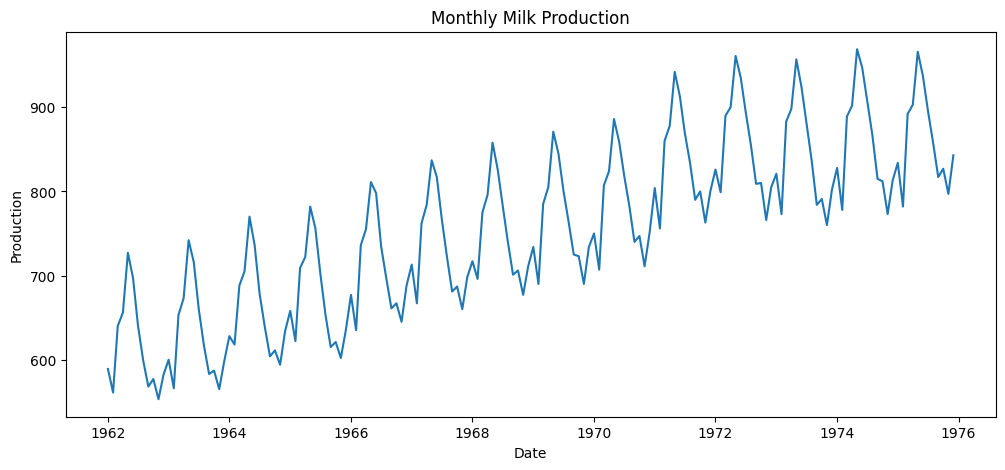

In [17]:
plt.figure(figsize=(12,5))
plt.plot(df.index, df['Production'])
plt.title("Monthly Milk Production")
plt.xlabel("Date")
plt.ylabel("Production")
plt.show()

In [18]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

scaled_data = scaler.fit_transform(
    df[['Production']]
)

print(scaled_data.shape)

(168, 1)


In [19]:
import numpy as np

def create_sequences(data, time_steps=12):

    X = []
    y = []

    for i in range(len(data)-time_steps):
        X.append(data[i:i+time_steps])
        y.append(data[i+time_steps])

    return np.array(X), np.array(y)

X, y = create_sequences(scaled_data, 12)

print("X Shape:", X.shape)
print("y Shape:", y.shape)

X Shape: (156, 12, 1)
y Shape: (156, 1)


In [20]:
print(X.shape)
print(y.shape)

(156, 12, 1)
(156, 1)


In [21]:
split = int(len(X) * 0.8)

X_train = X[:split]
X_test = X[split:]

y_train = y[:split]
y_test = y[split:]

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (124, 12, 1)
X_test : (32, 12, 1)
y_train: (124, 1)
y_test : (32, 1)


In [22]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense
from tensorflow.keras.callbacks import EarlyStopping

rnn_model = Sequential([
    SimpleRNN(50, activation='tanh',
              input_shape=(X_train.shape[1], X_train.shape[2])),
    Dense(1)
])

rnn_model.compile(
    optimizer='adam',
    loss='mse'
)

rnn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 50)             │         2,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,651 (10.36 KB)

 Trainable params: 2,651 (10.36 KB)

 Non-trainable params: 0 (0.00 B)

In [23]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

history_rnn = rnn_model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=16,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 4s 302ms/step - loss: 0.1089 - val_loss: 0.0496
Epoch 2/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.0422 - val_loss: 0.0243
Epoch 3/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0204 - val_loss: 0.0673
Epoch 4/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0109 - val_loss: 0.0040
Epoch 5/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0097 - val_loss: 0.0039
Epoch 6/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0051 - val_loss: 0.0161
Epoch 7/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0050 - val_loss: 0.0088
Epoch 8/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0034 - val_loss: 0.0043
Epoch 9/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0031 - val_loss: 0.0052
Epoch 10/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0028 - val_loss: 0.0067
Epoch 11/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0024 - val_loss: 0.0039
Epoch 12/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0022 - val_loss: 0.0036


In [24]:
from tensorflow.keras.layers import LSTM

lstm_model = Sequential([
    LSTM(50,
         activation='tanh',
         input_shape=(X_train.shape[1], X_train.shape[2])),
    Dense(1)
])

lstm_model.compile(
    optimizer='adam',
    loss='mse'
)

lstm_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 50)             │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,451 (40.82 KB)

 Trainable params: 10,451 (40.82 KB)

 Non-trainable params: 0 (0.00 B)

In [25]:
history_lstm = lstm_model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=16,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 121ms/step - loss: 0.1623 - val_loss: 0.2295
Epoch 2/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0542 - val_loss: 0.0377
Epoch 3/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0278 - val_loss: 0.0388
Epoch 4/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0307 - val_loss: 0.0268
Epoch 5/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0244 - val_loss: 0.0399
Epoch 6/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0258 - val_loss: 0.0358
Epoch 7/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0238 - val_loss: 0.0271
Epoch 8/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0235 - val_loss: 0.0254
Epoch 9/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0235 - val_loss: 0.0261
Epoch 10/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0230 - val_loss: 0.0288


In [26]:
from tensorflow.keras.layers import GRU

gru_model = Sequential([
    GRU(50,
        activation='tanh',
        input_shape=(X_train.shape[1], X_train.shape[2])),
    Dense(1)
])

gru_model.compile(
    optimizer='adam',
    loss='mse'
)

gru_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 50)             │         7,950 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,001 (31.25 KB)

 Trainable params: 8,001 (31.25 KB)

 Non-trainable params: 0 (0.00 B)

In [27]:
history_gru = gru_model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=16,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - loss: 0.2797 - val_loss: 0.4951
Epoch 2/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.1251 - val_loss: 0.2005
Epoch 3/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0414 - val_loss: 0.0535
Epoch 4/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0382 - val_loss: 0.0288
Epoch 5/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0395 - val_loss: 0.0361
Epoch 6/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0311 - val_loss: 0.0564
Epoch 7/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0303 - val_loss: 0.0632
Epoch 8/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0300 - val_loss: 0.0564
Epoch 9/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0294 - val_loss: 0.0427
Epoch 10/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0278 - val_loss: 0.0403


In [28]:
rnn_pred = rnn_model.predict(X_test)
lstm_pred = lstm_model.predict(X_test)
gru_pred = gru_model.predict(X_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 345ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step


In [29]:
y_test_actual = scaler.inverse_transform(y_test)

rnn_pred_actual = scaler.inverse_transform(rnn_pred)
lstm_pred_actual = scaler.inverse_transform(lstm_pred)
gru_pred_actual = scaler.inverse_transform(gru_pred)

In [31]:
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
import numpy as np

def evaluate(y_true, y_pred):

    rmse = np.sqrt(
        mean_squared_error(y_true, y_pred)
    )

    mae = mean_absolute_error(
        y_true, y_pred
    )

    mape = np.mean(
        np.abs((y_true - y_pred) / y_true)
    ) * 100

    return rmse, mae, mape

In [32]:
rnn_rmse, rnn_mae, rnn_mape = evaluate(
    y_test_actual,
    rnn_pred_actual
)

lstm_rmse, lstm_mae, lstm_mape = evaluate(
    y_test_actual,
    lstm_pred_actual
)

gru_rmse, gru_mae, gru_mape = evaluate(
    y_test_actual,
    gru_pred_actual
)

comparison = pd.DataFrame({
    "Model":["RNN","LSTM","GRU"],
    "RMSE":[rnn_rmse,lstm_rmse,gru_rmse],
    "MAE":[rnn_mae,lstm_mae,gru_mae],
    "MAPE":[rnn_mape,lstm_mape,gru_mape]
})

comparison

,Model,RMSE,MAE,MAPE
0,RNN,17.985801,14.763054,1.739686
1,LSTM,199.787871,189.725122,21.763776
2,GRU,294.752469,286.547873,33.081040


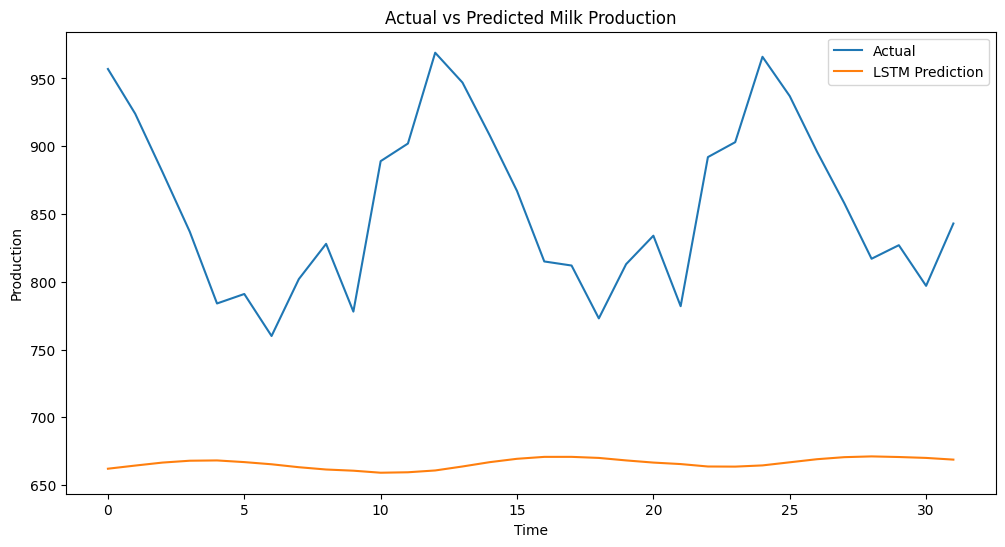

In [33]:
plt.figure(figsize=(12,6))

plt.plot(
    y_test_actual,
    label='Actual'
)

plt.plot(
    lstm_pred_actual,
    label='LSTM Prediction'
)

plt.title("Actual vs Predicted Milk Production")
plt.xlabel("Time")
plt.ylabel("Production")
plt.legend()
plt.show()

In [35]:
future_input = scaled_data[-12:]
future_input = future_input.reshape(1, 12, 1)

future_predictions = []

for i in range(12):

    pred = lstm_model.predict(
        future_input,
        verbose=0
    )

    future_predictions.append(pred[0,0])

    pred_reshaped = pred.reshape(1,1,1)

    future_input = np.concatenate(
        (future_input[:,1:,:], pred_reshaped),
        axis=1
    )

future_predictions = np.array(
    future_predictions
).reshape(-1,1)

future_predictions = scaler.inverse_transform(
    future_predictions
)

print(future_predictions)

[[668.0766 ]
 [662.5396 ]
 [656.50806]
 [649.1051 ]
 [641.70087]
 [633.912  ]
 [626.8589 ]
 [620.6781 ]
 [615.31445]
 [610.7633 ]
 [606.44885]
 [602.8001 ]]


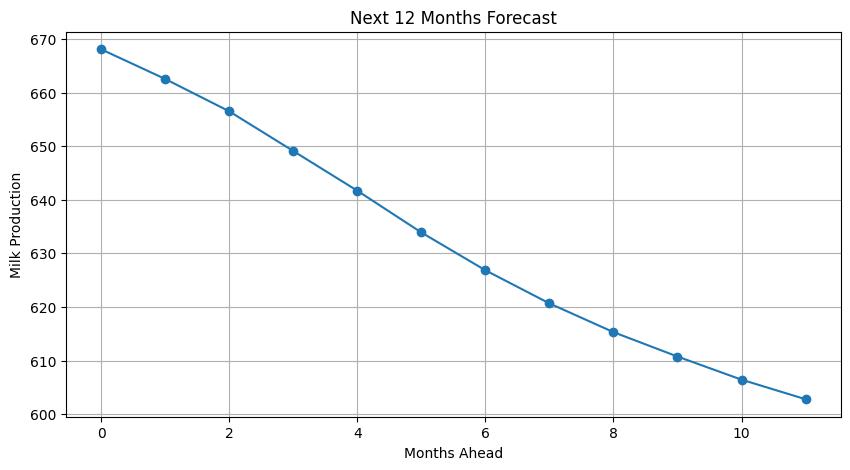

In [36]:
plt.figure(figsize=(10,5))

plt.plot(
    future_predictions,
    marker='o'
)

plt.title("Next 12 Months Forecast")
plt.xlabel("Months Ahead")
plt.ylabel("Milk Production")

plt.grid(True)
plt.show()

In [37]:
future_dates = pd.date_range(
    start=df.index[-1] + pd.DateOffset(months=1),
    periods=12,
    freq='MS'
)

forecast_df = pd.DataFrame({
    'Date': future_dates,
    'Forecast': future_predictions.flatten()
})

forecast_df

,Date,Forecast
0,1976-01-01,668.076599
1,1976-02-01,662.539612
2,1976-03-01,656.508057
3,1976-04-01,649.105103
4,1976-05-01,641.700867
5,1976-06-01,633.911987
6,1976-07-01,626.858887
7,1976-08-01,620.678101
8,1976-09-01,615.314453
9,1976-10-01,610.763306
